In [1]:
import pandas as pd

df = pd.read_csv(
    r"../data/crime_feature_engineered.csv"
)

print(df.shape)
df.head()

(492933, 35)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,IsWeekend,Season,Crime_Severity_Score,Lat_Bin,Lon_Bin,Crime_Type_Encoded,Location_Encoded,District_Encoded,Latitude_Scaled,Longitude_Scaled
0,8466079,HV142615,2012-02-02 15:08:00,066XX S ST LAWRENCE AVE,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,...,0,Winter,2.0,6,15,18,142,15,-0.796001,1.026779
1,10039292,HY229009,2015-04-11 17:30:00,069XX S JUSTINE ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,1,Spring,1.0,6,13,6,17,20,-0.868525,0.144205
2,8656424,HV331830,2012-06-12 21:21:00,051XX W NORTH AVE,041A,BATTERY,AGGRAVATED: HANDGUN,PARKING LOT/GARAGE(NON.RESID.),False,False,...,0,Summer,3.0,14,8,2,114,14,0.771923,-1.421922
3,1527209,G277177,2001-05-13 23:30:00,044XX S INDIANA AV,0915,MOTOR VEHICLE THEFT,"TRUCK, BUS, MOTOR HOME",STREET,False,False,...,1,Spring,3.0,8,15,17,147,10,-0.324950,0.842742
4,1583223,G348885,2001-06-12 07:00:00,060XX S FRANCISCO AV,0810,THEFT,OVER $500,RESIDENCE,False,True,...,0,Summer,2.0,7,11,31,121,21,-0.687510,-0.422679


In [4]:
features = [
    'Hour',
    'Month',
    'IsWeekend',
    'Crime_Severity_Score',
    'Crime_Type_Encoded',
    'Location_Encoded',
    'District_Encoded',
    'Latitude_Scaled',
    'Longitude_Scaled'
]

X = df[features]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [17]:
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.22011516 0.36518678 0.48218701 0.59480756 0.70427034 0.80832493
 0.88970787 0.96280001 1.        ]


In [18]:
n_components = np.argmax(
    cumulative_variance >= 0.70
) + 1

print(
    f"Components needed for 70% variance: {n_components}"
)

Components needed for 70% variance: 5


In [19]:
pca_final = PCA(
    n_components=5
)

X_pca_final = pca_final.fit_transform(
    X_scaled
)

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[
        'PC1',
        'PC2',
        'PC3',
        'PC4',
        'PC5'
    ],
    index=features
)

In [20]:
feature_importance = (
    loadings.abs()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print(feature_importance)

Location_Encoded        1.673776
IsWeekend               1.581267
Month                   1.452839
Crime_Severity_Score    1.325388
Crime_Type_Encoded      0.942106
Hour                    0.899798
Longitude_Scaled        0.849815
Latitude_Scaled         0.733540
District_Encoded        0.649880
dtype: float64


In [22]:
from sklearn.manifold import TSNE

sample_tsne = df.sample(
    n=5000,
    random_state=42
)

X_tsne = sample_tsne[
    features
]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne_2d = tsne.fit_transform(X_tsne)

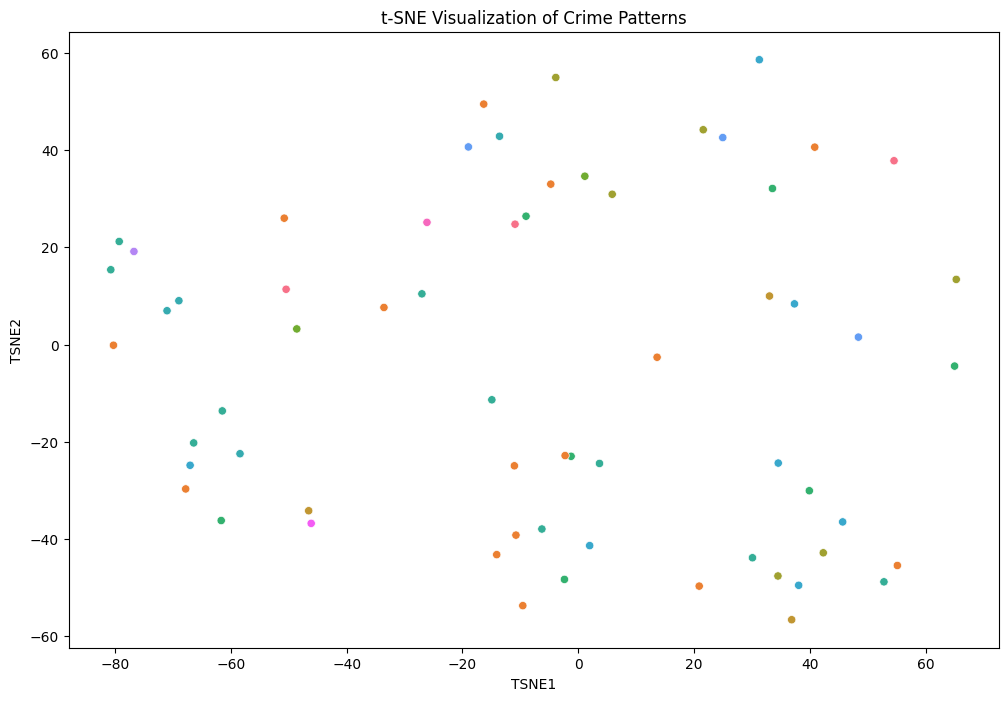

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tsne_df = pd.DataFrame(
    X_tsne_2d,
    columns=['TSNE1', 'TSNE2']
)

tsne_df['Crime_Type'] = (
    sample_tsne['Primary Type']
)

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='Crime_Type',
    legend=False
)

plt.title(
    "t-SNE Visualization of Crime Patterns"
)

plt.show()